Importing libraries and defining input sequences to be given to the network.

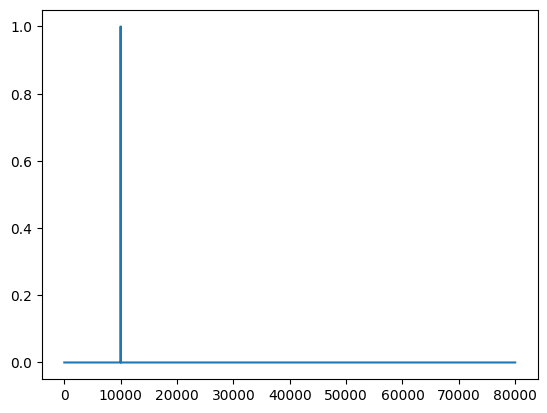

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats

#stable input of 500 ms period metronome, a vector of 0s with a 1 every 5000 entries
stable_input = np.zeros(5000 * 10)

for i in range(0,10):
    stable_input[i*5000] = 1


#lets just add twenty 510 ms stimuli onto the end of stable_input, adding a vector of 0s with a 1 every 5100 entries
thaut_fig4a = np.zeros(5100 * 20)

for i in range(0,20):
    thaut_fig4a[i*5100] = 1 

thaut_fig4a = np.concatenate((stable_input,thaut_fig4a))

#same thing for 550ms stimuli, adding a vector of 0s with a 1 every 5500 entries
thaut_fig2a = np.zeros(5500*20)

for i in range(0,20):
    thaut_fig2a[i*5500] = 1 

thaut_fig2a = np.concatenate((stable_input,thaut_fig2a))

#same thing for 550ms stimuli, adding a vector of 0s with a 1 every 5200 entries
thaut_fig3a = np.zeros(5200*20)

for i in range(0,20):
    thaut_fig3a[i*5200] = 1 

thaut_fig3a = np.concatenate((stable_input,thaut_fig3a))

# these will be runs that contain two tempo switches to demonstrate how tapping stability increases over time

#stable input of 500 ms period metronome, a vector of 0s with a 1 every 5000 entries
stable_input = np.zeros(5000 * 6)

for i in range(0,6):
    stable_input[i*5000] = 1

first_switch  = np.zeros(5100 * 10)

for i in range(0,10):
    first_switch[i*5100] = 1

second_switch  = np.zeros(5200 * 10)

for i in range(0,10):
    second_switch[i*5200] = 1

fast_switch = np.concatenate((stable_input,first_switch,second_switch))

# and another time but with a more tapping at the first tempo

first_switch  = np.zeros(5100 * 15)

for i in range(0,15):
    first_switch[i*5100] = 1

second_switch  = np.zeros(5200 * 10)

for i in range(0,10):
    second_switch[i*5200] = 1

slow_switch = np.concatenate((stable_input,first_switch,second_switch))

#stable input of 500 ms period metronome, a vector of 0s with a 1 every 5000 entries
long_stable = np.zeros(5000 * 16)

long_stable[10000] = 1

short_stable = np.zeros(15000 * 4)

for i in range(0,4):
    short_stable[i*15000] = 1

plt.plot(long_stable)


The neural network model of parallel CSNTC loops:

In [12]:
class b_ganglia:
    def __init__(self,n_loops,time_steps,exc_spread = 15):

        self.n_loops = n_loops
        self.n_steps = time_steps
        
        initial_activity = 0.1
        #activations for all units and matrix to hold input
        self.a_sd1 = np.zeros((time_steps, n_loops))+initial_activity
        self.in_sd1 = np.zeros((time_steps, n_loops))
        self.a_sd2 = np.zeros((time_steps, n_loops))+initial_activity
        self.in_sd2 = np.zeros((time_steps, n_loops))
        self.a_stn = np.zeros((time_steps, n_loops))+initial_activity
        self.in_stn = np.zeros((time_steps, n_loops))
        self.a_gpi = np.ones((time_steps, n_loops))+initial_activity
        self.in_gpi = np.ones((time_steps, n_loops))
        self.a_gpe = np.zeros((time_steps, n_loops))+initial_activity
        self.a_tha = np.zeros((time_steps, n_loops))+initial_activity
        self.a_ctx = np.zeros((time_steps, n_loops))+initial_activity
        self.in_ctx = np.zeros((time_steps, n_loops))
        self.in_tha = np.zeros((time_steps, n_loops))

        #vector to hold changing dopamine levels
        self.da = np.ones((time_steps))

        #vector to hold the inputs...
        self.a_input = np.zeros((time_steps, n_loops))


        #variable to keep track of what step we are currently on
        self.c = 0

        #### weights connecting all the layers #####

        #cortico-striatal connections are topographical, but also overlapping, thus we will use the Guassians we have previously shown work
        #first change from the original version, we will not have "input"-striatum connections, we will have a single cortical layer at the top receiving both "input" and thalamic input

        #initializing the matrices to hold all the weights
        self.w_ctx_sd1 = np.zeros((n_loops,n_loops))
        self.w_ctx_sd2 = np.zeros((n_loops,n_loops))


        #the weights from input to the cortex will just be the identity matrix I think
        self.w_inp_ctx = np.identity(n_loops)# * 0.32


        self.unit_ids = np.arange(0,n_loops,1) 

        w_ctx_sd = 1
        
        for i in range(0,n_loops):
            #inserting the Guassians into the matrix
            #wider-spreading connectivities
            self.w_ctx_sd1[i] = stats.norm.pdf(self.unit_ids, i, exc_spread) / np.max(stats.norm.pdf(self.unit_ids, i, exc_spread)) *w_ctx_sd/exc_spread #the dividing by the max ensure the weight distribution has a max of 1 before any other changes, just keeps the weights reasonable I think
            self.w_ctx_sd2[i] = stats.norm.pdf(self.unit_ids, i, exc_spread) / np.max(stats.norm.pdf(self.unit_ids, i, exc_spread)) *w_ctx_sd/exc_spread

        self.sd1_bias = -.2
        self.sd2_bias = -.2
        
        #second attempt at this, implementing pure 1-to-1 connectivity
        self.w_ctx_stn = np.identity(n_loops) * 2.5#1
        self.stn_bias = 0
        
        self.w_sd1_gpi = np.identity(n_loops) * -3#1.5
        self.gpi_bias = .4
        
        self.w_sd2_gpe = np.identity(n_loops) * -2#1.5
        self.gpe_bias = .4
        
        self.w_gpe_stn = np.identity(n_loops) * -1#
        self.w_gpe_gpi = np.identity(n_loops) * -0.1 #01
        
        self.w_gpi_tha = np.identity(n_loops) * -3 #1.2
        self.tha_bias = .6
        
        self.w_tha_ctx = np.identity(n_loops) * 3 #1.2
        self.ctx_bias = -.2
        
        #the STN has dense connectivity to the output nuclei so we can just set these as an array of ones
        self.w_stn_gpi = np.ones((self.n_loops,self.n_loops)) * 0.1
        self.w_stn_gpe = np.ones((self.n_loops,self.n_loops)) * 0.1


    #uses euler integration to calculate the activation at each unit in the model of the basal ganglia 
    def run(self, input,dop_level,input_off,sim_type,start_tempo,input_noise=0,unit_noise=0, ctx_noise = 0, da_noise = 0):

        self.a_input = input + input_noise * np.random.normal(size = (len(input), self.n_loops))
        self.unit_noise = unit_noise
        self.ctx_noise = ctx_noise
        self.da_noise = da_noise
        np.random.seed(seed=123456789)

        #likely easier to just define the parameters inside this function...
        dt = 0.002
        tau = 0.01
        #time constant 
        h= dt/tau
        


        #define the sensitivies to dopamine and normal response
        sd1_bl = 0.7
        sd1_DA = 0.35
        sd2_bl = .5
        sd2_DA = 4

        
        #network dopamine throughout simulation
        self.da = np.ones(len(self.a_input))
        da_thresh = np.ones(len(self.a_input)) * 0 #the level which dopamine is currently approaching at any given time 
        da_tau = np.ones(len(self.a_input)) * 25000 # the decay rate (in time steps)

        #start with the assumption the person already knows the ISI at start of simulation (all of our cases will start with 500 ms or 50 steps)
        isi = start_tempo
        iti = start_tempo

        #vector to hold whether or not a tap is produced each step...
        self.tapout = np.zeros(len(self.a_input))
        #self.tapout[0] = 1 #this may cause problems with the metronome stuff later

        self.tap_proximity = np.zeros(len(self.a_input))
        self.tap_proximity[0] = 1
        
        #i think the input should also be dependent on the previous ISIs, you probably aren't 100% confident that a switch had been made
        #these are used to see if a tap and stimulus have arrived and need to be compared to eachother to make phase/tempo adjustments (nauseating code but what can you do)
        stim_here = False
        tap_here = False

        #these are the indices at which the last tap or stimulus took place
        last_stim = 0
        last_tap = 0

        #variable to hold the average error across the simulation
        avg_error = 0
        #variable to hold the last observed error
        error = 0

        #the fractional rate at which phase corrections occur
        phase_corr_rate = 1/4
        #controls how strongly dopamine changes in response to error (has to be small as we are moving from measuring error in steps to dopamine levels <= 1)
        dop_scaling_factor = 1/1900

        #eulers method

        
        self.tempo_report = np.zeros(self.n_steps-1)

        for i in range(self.n_steps - 1):#-6000):
            
            self.in_ctx[i+1] = np.matmul(self.a_input[i], self.w_inp_ctx) + np.matmul(self.a_tha[i], self.w_tha_ctx) +self.ctx_bias
            self.a_ctx[i+1] = self.a_ctx[i] + h * (self.non_lin(self.in_ctx[i+1] + np.random.normal(size = self.n_loops) * self.unit_noise/np.sqrt(dt) ) - self.a_ctx[i])

            sd1_mult = (sd1_bl + sd1_DA * self.da[i])
            self.in_sd1[i+1] = sd1_mult * np.matmul(self.a_ctx[i], self.w_ctx_sd1) +self.sd1_bias 
            self.a_sd1[i+1] = self.a_sd1[i] + h * (self.non_lin(self.in_sd1[i+1] + np.random.normal(size = self.n_loops) * self.unit_noise/np.sqrt(dt) + np.random.normal(size = self.n_loops) * self.ctx_noise/np.sqrt(dt)) - self.a_sd1[i])
            
            sd2_mult = (1/(sd2_bl + sd2_DA * self.da[i]))
            self.in_sd2[i+1] = sd2_mult * np.matmul(self.a_ctx[i], self.w_ctx_sd2) +self.sd2_bias 
            self.a_sd2[i+1] = self.a_sd2[i] + h * (self.non_lin(self.in_sd2[i+1] + np.random.normal(size = self.n_loops) * self.unit_noise/np.sqrt(dt)+ np.random.normal(size = self.n_loops) * self.ctx_noise/np.sqrt(dt)) - self.a_sd2[i])

            self.in_stn[i+1] = np.matmul(self.a_ctx[i], self.w_ctx_stn) + np.matmul(self.a_gpe[i], self.w_gpe_stn) +self.stn_bias
            self.a_stn[i+1] = self.a_stn[i] + h * (self.non_lin(self.in_stn[i+1] + np.random.normal(size = self.n_loops) * self.unit_noise/np.sqrt(dt)) - self.a_stn[i])
            
            self.a_gpe[i+1] = self.a_gpe[i] + h * (self.non_lin(np.matmul(self.a_sd2[i], self.w_sd2_gpe) + np.matmul(self.a_stn[i], self.w_stn_gpe) + self.gpe_bias + np.random.normal(size = self.n_loops) * self.unit_noise/np.sqrt(dt)) - self.a_gpe[i])
            
            self.in_gpi[i+1] = np.matmul(self.a_sd1[i], self.w_sd1_gpi) + np.matmul(self.a_stn[i], self.w_stn_gpi) + np.matmul(self.a_gpe[i], self.w_gpe_gpi)  + self.gpi_bias
            self.a_gpi[i+1] = self.a_gpi[i] + h * (self.non_lin(self.in_gpi[i+1] + np.random.normal(size = self.n_loops) * self.unit_noise/np.sqrt(dt)) - self.a_gpi[i]) 
            
            self.in_tha[i+1] = np.matmul(self.a_gpi[i], self.w_gpi_tha)  + self.tha_bias
            self.a_tha[i+1] = self.a_tha[i] + h * (self.non_lin(self.in_tha[i+1] + np.random.normal(size = self.n_loops) * self.unit_noise/np.sqrt(dt)) - self.a_tha[i]) 
            
            if sim_type== 'metronome':
                
                self.da[i+1] = self.da[i] - ((self.da[i] - da_thresh[i])/da_tau[i])
            elif sim_type=='self_paced':
                self.da[i+1] = self.da[i] + (dop_level - self.da[i])*dt*1 + np.random.normal()*np.sqrt(dt)*self.da_noise
            else:
                raise Exception("Invalid sim_type argument, either enter 'metronome' or 'self_paced' to simulate syncrhonization to an external stimuli or self paced continuation tapping respectivly")
            
            #record the most salient tempo for the current step
            self.tempo_report[i] = self.index_to_tempo(np.sum((self.unit_ids ) * self.a_tha[i]) / np.sum(self.a_tha[i]))
            self.tap_proximity[i+1] = self.tap_proximity[i] - dt *1000/self.tempo_report[i]

            if self.tap_proximity[i+1] <0:
                self.tap_proximity[i+1] = 1
                self.tapout[i] = 1
            
            #if sim_type == 'metronome':
            #    #in this case, the stimulus variable represents the external sensory stimuli from the metronome and tapout variable holds the timings of the produced taps

                #if i>0: #probably easiest to have the stimulus always start on a tap, don't want this to cause errors tho
                #    if self.stimulus[i]==1:
                #            #noting that there was a perceived stimulus
                #            stim_here = True
                #            #reset perceived ISI based on most recent stimulus arrival

#                            isi = (i - last_stim)
#                            last_stim = i
#                if self.tapout[i-2000] == 1: #we likely do not set the timing of our next tap immedietly upon tapping, but have to have some reaction/processing time, thus we set the tempo of the next tap some time after we make our initial tap
                        #noting that a tap has occured
#                        tap_here = True
#                        last_tap = i - 2000

                        #if we have received stimuli from our own tap, note where the following tap would be, if phase adjustment does not occur
#                        iti = (np.sum((unit_ids + 350) * self.a_tha[i]) / np.sum(self.a_tha[i])) * 10

                        #set the timing of the next tap, adjusted by any phase error from the last correction
#                        next_tap = int(i-2000+iti) - int(error * phase_corr_rate) 
#                        self.tapout[next_tap] = 1

                
                #if there is both a tap and stimulus we can now make a phase correction
 #               if tap_here == True and stim_here == True:
 #                   error = last_tap - last_stim #we are storing the last error

                    #we want the dopamine levels to depend on several taps, we will use exponential averaging to do this, as it maintains that the most recent tap is more important than more distant ones
 #                   avg_error = 0.4 * avg_error + 0.6 * error

                    #adjust the dopamine in the network in response to any error
#                    da_thresh[i:i+300] =  (1 - np.abs(error * dop_scaling_factor)) * dop_level
#                    da_tau[i:i+300] = 300

                    #now we are waiting for the next set of taps and stimuli
#                    stim_here = False
#                    tap_here = False

            #if sim_type == 'self_paced' and i > 1500:
                
                #in this case, the stimulus variable will hold both the "external" sensory stimuli and produced tap timings, as they are known to be the same in this case
                #if self.stimulus[i-2000] == 1:
                #        last_stim = i
                #        isi = (np.sum((unit_ids + 350) * self.a_tha[i]) / np.sum(self.a_tha[i])) * 10
                #        self.stimulus[int(i+isi)-2000] = 1


        #calculating the ISIs and ITIs for the simulation        
        #stim_indices = [i for i in range(len(self.stimulus)) if self.stimulus[i]==1]
        #self.ISI_report = np.diff(stim_indices)/10
        #calculate the inter-tap intervals
        tap_indices = [i for i in range(len(self.tapout)) if self.tapout[i]==1]
        self.ITI_report = np.diff(tap_indices)*dt*1000



        return None

    #non-linearity to generate activations
    def non_lin(self,vec):

        #apply non-linearity
        x = np.tanh(vec)
        
        #set any negative values to 0
        for i in range(self.n_loops):
            if x[i] < 0:
                x[i] = 0
        
        return x


    def tempo_to_index(self,tempo):
        return int((np.log(tempo) - 5.8)/1.3*self.n_loops)

    def index_to_tempo(self,index):
        return np.exp(index *1.3/ self.n_loops + 5.8)



    def display(self):

        titles = ('Input','Ctx', 'SD1', 'SD2', "STN", "GPi/SNpr", "GPe", "Tha")
        data = (self.a_input,  self.a_ctx, self.a_sd1, self.a_sd2, self.a_stn, self.a_gpi, self.a_gpe, self.a_tha)

        fig, ax = plt.subplots(9)
        fig.set_figheight(20)
        fig.set_figwidth(15)
        fig.tight_layout()

        ax[0].plot(self.da[2000:70000])
        ax[0].set_title("Dopamine levels")

        for i in range(1,9):
            im = ax[i].imshow(data[i-1][0:70000].T,aspect='auto')
            ax[i].set_title(str(titles[i-1]+ ' layer activations'))
            plt.colorbar(im, ax=ax[i])
        
        #this code plots the activations of all units at different time steps for each layer, it can be helpful for diagnosing problems but also takes a long time to plot and doesn't provide a ton of
        #new information, so we can leave it commented out for now
        '''
        fig2, ax = plt.subplots(8)
        fig2.set_figheight(20)
        fig2.set_figwidth(15)
        fig2.tight_layout()
        
        for i in range(8):
            time_steps = np.arange(5000,self.n_steps,5000)
            for step in time_steps:
                ax[i].plot(data[i][step + 500],alpha=0.5,label= str("step = "+str(step)))
                ax[i].set_title(titles[i])
                #ax[i].legend()
        '''
        
        plt.figure(3)
        #plt.plot(self.ISI_report, alpha=0.5, label="ISIs",marker='x')
        plt.plot(self.ITI_report, alpha=0.5, label="ITIs",marker="x")
        plt.title("Received ISIs and produced ITIs")
        plt.xlabel('Stimulus Number')
        plt.ylabel('Inter-tap Interval (ms)')
        plt.legend()

        plt.figure(4)
        plt.plot(self.tempo_report)
        plt.title("Tempo report")
        plt.xlabel('Time step')
        plt.ylabel('Tempo')
        #plt.ylim((450,550))
    
        plt.show

    def display2(self):
        
        
        titles = ('Input','Ctx', 'SD1', 'SD2', "STN", "GPi/SNpr", "Tha")
        data = (self.a_input, self.in_ctx, self.in_sd1, self.in_sd2, self.in_stn, self.in_gpi, self.in_tha)

        fig, ax = plt.subplots(len(data))
        fig.set_figheight(15)
        fig.set_figwidth(15)
        fig.tight_layout()

        for i in range(0,len(data)):
            im = ax[i].imshow(data[i][0:70000].T,aspect='auto')
            ax[i].set_title(str(titles[i]+ ' layer input'))
            plt.colorbar(im, ax=ax[i])

        fig2, ax = plt.subplots(1)
        fig2.set_figheight(3)
        fig2.set_figwidth(14.3)

        ax.plot(self.da[20:140000])
        ax.set_ylim([0.2,1.1])


        plt.figure(3)
        #saliences = np.exp(np.argmax(self.a_tha, axis=1) / n_loops + 6)
        saliences = self.index_to_tempo(np.argmax(self.a_tha, axis=1))
        plt.plot(saliences)
        plt.title("Most salient ITIs across simulation")
        plt.xlabel('Time step')
        plt.ylabel('Most salient ITI (ms)')
    
        plt.show

    def display3(self):

        data = (self.a_input, self.a_ctx, self.a_tha)

        fig, ax = plt.subplots(3)
        fig.set_figheight(5)
        fig.set_figwidth(15)
        fig.tight_layout()

        for i in range(0,3):
            im = ax[i].imshow(data[i][20:140000].T,aspect='auto')
            plt.colorbar(im, ax=ax[i])

        fig2, ax = plt.subplots(1)
        fig2.set_figheight(1.66)
        fig2.set_figwidth(14.3)

        ax.plot(self.da[20:140000])
        ax.set_ylim([0.2,1.1])


        plt.figure(3)
        #plt.plot(self.ISI_report, alpha=0.5, label="ISIs",marker='x',linewidth=1.5)
        plt.plot(self.ITI_report, alpha=0.5, label="ITIs",marker="x",linewidth=1.5)
        plt.title("Received ISIs and produced ITIs")
        plt.xlabel('Stimulus Number')
        plt.ylabel('Inter-tap Interval (ms)')
        plt.legend()


        plt.figure(4)
        saliences = np.argmax(self.a_tha, axis=1) + 350
        plt.plot(saliences[10000:-10000])
        plt.title("Most salient ITIs across simulation")
        plt.xlabel('Time step')
        plt.ylabel('Most salient ITI (ms)')
    
        plt.show

# Switching Manipulation:

In [3]:
bg1 = b_ganglia(n_loops=200, time_steps=len(thaut_fig4a), input_noise=0)
bg1.run(thaut_fig4a,dop_level=1, sim_type='metronome')
bg1.display2()


TypeError: b_ganglia.__init__() got an unexpected keyword argument 'input_noise'

In [199]:
bg1 = b_ganglia(n_loops=3200, time_steps=len(thaut_fig3a),input_noise=0)
bg1.run(thaut_fig3a, dop_level=1, sim_type='metronome')
bg1.display2()

TypeError: b_ganglia.__init__() got an unexpected keyword argument 'input_noise'

In [200]:
bg1 = b_ganglia(n_loops=200, time_steps=len(thaut_fig2a),input_noise=0)
bg1.run(thaut_fig2a, dop_level=1, sim_type='metronome')
bg1.display2()

TypeError: b_ganglia.__init__() got an unexpected keyword argument 'input_noise'

In [219]:
bg1 = b_ganglia(n_loops=300, time_steps=len(long_stable[0:20000]),noise=1)
bg1.run(long_stable[0:20000],dop_level=1, sim_type='self_paced')


TypeError: b_ganglia.__init__() got an unexpected keyword argument 'noise'

In [ ]:
bg2 = b_ganglia(n_loops=300, time_steps=len(long_stable),noise=1)
bg2.run(long_stable,dop_level=0.95)

In [ ]:
bg3 = b_ganglia(n_loops=300, time_steps=len(long_stable),noise=1)
bg3.run(long_stable,dop_level=0.97)

In [ ]:
bg1.display()

In [ ]:
bg2.display()

In [ ]:
plt.figure(figsize=(6,10))

plt.plot(bg1.ITI_report,label='Baseline',alpha=0.8,color="cornflowerblue",linewidth=2)
plt.plot(bg3.ITI_report,label='3% reduction',alpha=0.8,color='green',linewidth=2)
plt.plot(bg2.ITI_report,label='5% reduction',alpha=0.8,color='orange',linewidth=2)
plt.legend(loc='lower left',fontsize=14)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.ylabel("Inter-tap Interval", fontsize=16)
plt.xlabel("Tap Number", fontsize=16)


In [ ]:
vars = np.array((np.var(bg1.ITI_report),
                np.var(bg3.ITI_report),
                np.var(bg2.ITI_report)
))

plt.figure(figsize=(3,7))
plt.bar((' ','  ','   '),vars,color=["cornflowerblue","green","orange"],alpha=0.6,width=1)
plt.ylabel("variance",fontsize="14")
#plt.title("Variance of produced interval")


In [ ]:
print(np.var(bg1.ITI_report))
print(np.var(bg2.ITI_report))

# Fig 2a-b Demo of Attractor Maintenance


In [13]:
n_loops=250
start_tempo=650
input_spread = 2
input_0 = np.zeros((100000, n_loops))

bg1 = b_ganglia(n_loops=n_loops, time_steps=len(input_0), exc_spread = 10)

input_0[0:2000] = (stats.norm.pdf(bg1.unit_ids, bg1.tempo_to_index(start_tempo), input_spread) / np.max(stats.norm.pdf(bg1.unit_ids, bg1.tempo_to_index(start_tempo), input_spread)))

bg1.run(input_0,dop_level=1,input_off=False,unit_noise=0, da_noise = 0, sim_type='self_paced',start_tempo=start_tempo, input_noise = 0, ctx_noise = .015)

#bg1.ITI_report

#bg1.display()
#bg1.display2()


In [14]:
n_loops=250
start_tempo=650
input_spread = 2
input_0 = np.zeros((100000, n_loops))

bg2 = b_ganglia(n_loops=n_loops, time_steps=len(input_0), exc_spread = 10)


input_0[0:2000] = (stats.norm.pdf(bg2.unit_ids, bg2.tempo_to_index(start_tempo), input_spread) / np.max(stats.norm.pdf(bg2.unit_ids, bg2.tempo_to_index(start_tempo), input_spread)))

bg2.run(input_0,dop_level=0.70,input_off=False,unit_noise=0, da_noise = 0, sim_type='self_paced',start_tempo=start_tempo, input_noise = 0, ctx_noise = .015)
#bg2.display()
#bg2.display2()

In [15]:
n_loops=250
start_tempo=650
input_spread = 2
input_0 = np.zeros((100000, n_loops))

bg3 = b_ganglia(n_loops=n_loops, time_steps=len(input_0), exc_spread = 10)


input_0[0:2000] = (stats.norm.pdf(bg3.unit_ids, bg3.tempo_to_index(start_tempo), input_spread) / np.max(stats.norm.pdf(bg3.unit_ids, bg3.tempo_to_index(start_tempo), input_spread)))

bg3.run(input_0,dop_level=0.5,input_off=False,unit_noise=0, da_noise = 0, sim_type='self_paced',start_tempo=start_tempo, input_noise = 0, ctx_noise = .015)

16
21.341445480443298
23.223319638891482
39.166368345382864


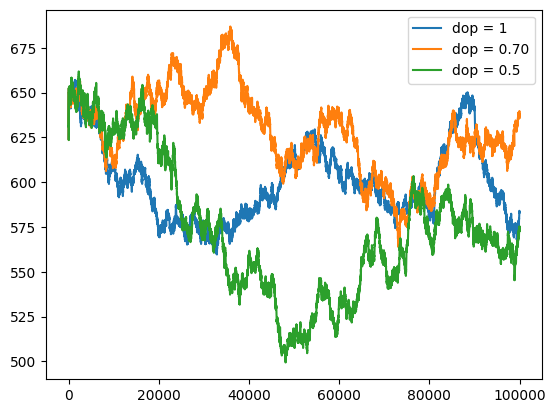

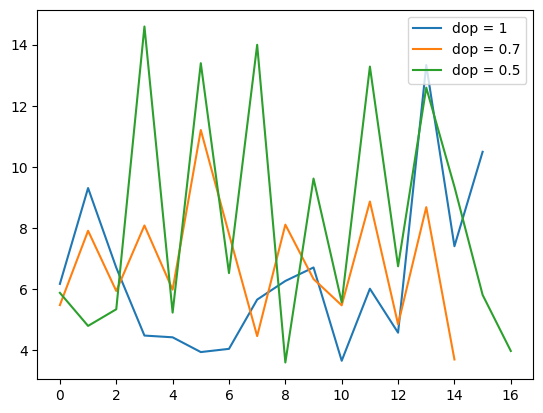

In [16]:
plt.figure()
plt.plot(bg1.tempo_report,label = 'dop = 1')

plt.plot(bg2.tempo_report, label = 'dop = 0.70')

plt.plot(bg3.tempo_report, label = 'dop = 0.5')

plt.legend()

bg1_std = np.zeros(int(len(bg1.ITI_report)/20))
bg2_std = np.zeros(int(len(bg2.ITI_report)/20))
bg3_std = np.zeros(int(len(bg3.ITI_report)/20))


print(int(len(bg1.ITI_report)/20))
for i in range( int(len(bg1.ITI_report)/20)):
    bg1_std[i]=np.std(bg1.ITI_report[i*20:(i+1)*20])

for i in range( int(len(bg2.ITI_report)/20)):
    bg2_std[i]=np.std(bg2.ITI_report[i*20:(i+1)*20])

for i in range( int(len(bg3.ITI_report)/20)):
    bg3_std[i]=np.std(bg3.ITI_report[i*20:(i+1)*20])



plt.figure()
plt.plot(bg1_std, label='dop = 1')
plt.plot(bg2_std, label='dop = 0.7')
plt.plot(bg3_std, label = 'dop = 0.5')
plt.legend()

print(np.std(bg1.tempo_report))
print(np.std(bg2.tempo_report))
print(np.std(bg3.tempo_report))


(0.0, 120.0)

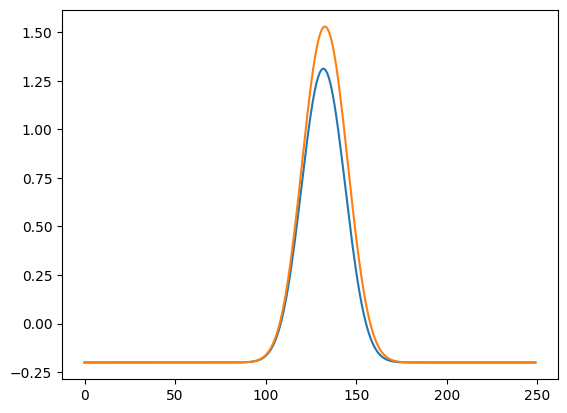

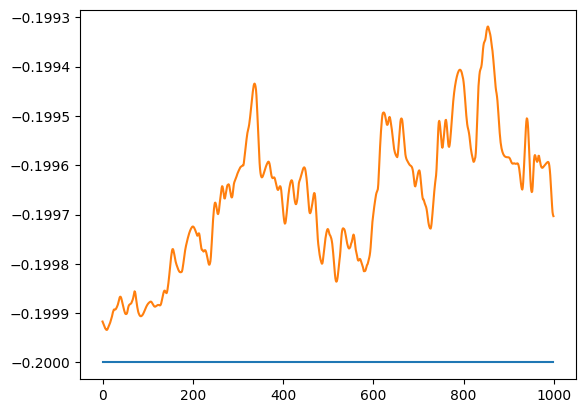

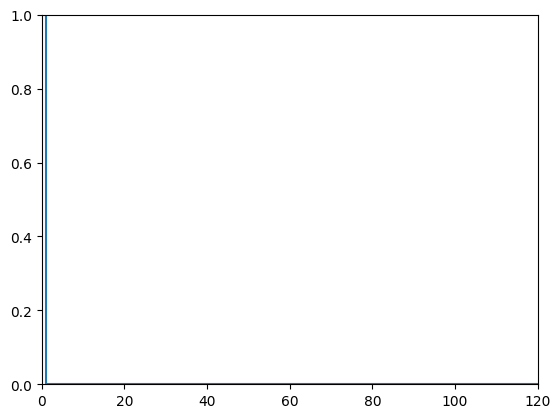

In [6]:

plt.figure()
plt.plot(bg1.in_sd1[6000,:])
plt.plot(bg2.in_sd1[6000,:])
plt.figure()
plt.plot(bg1.in_sd1[4000:5000, 20])
plt.plot(bg1.in_sd1[4000:5000, 180])

plt.figure()
plt.plot(np.abs(np.fft.fft(bg2.in_sd1[2000:5000, 20]))**2)

plt.ylim((0,1))
plt.xlim((0,120))

#bg2.display2()


#bg1.display2()

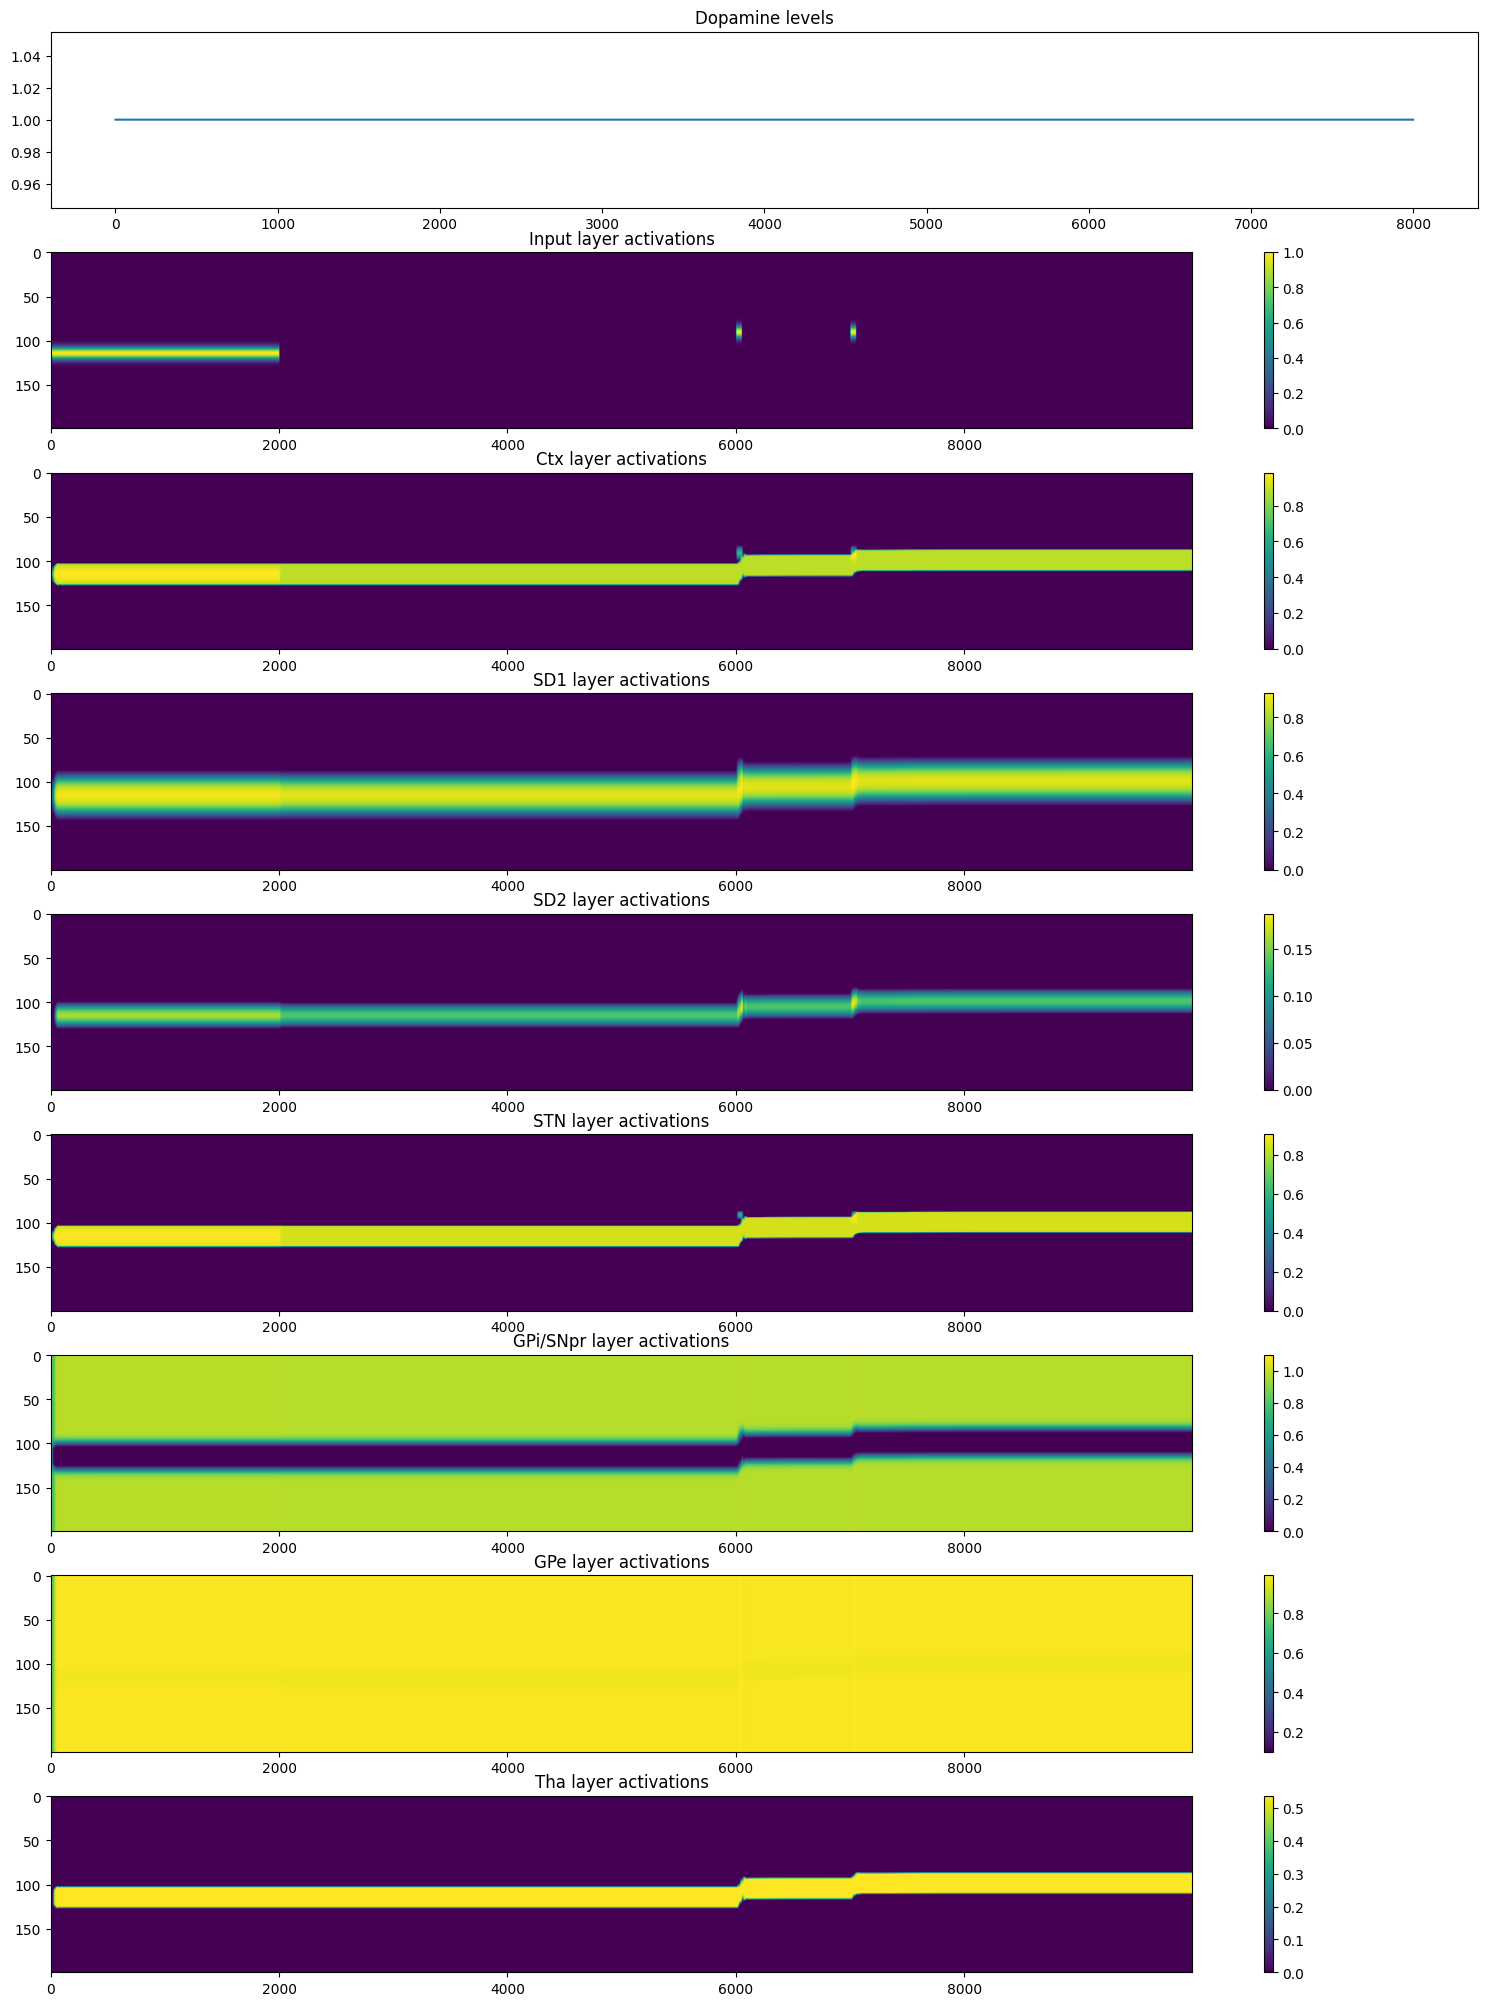

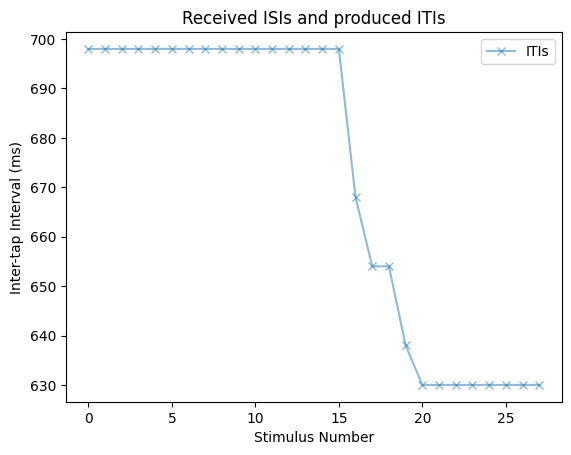

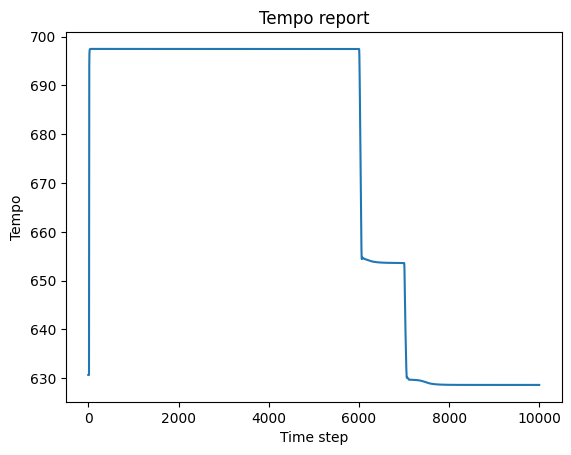

In [140]:
n_loops=200
start_tempo=700
next_tempo = 600
input_spread = 5
input_accel = np.zeros((10000, n_loops))

bg3 = b_ganglia(n_loops=n_loops, time_steps=len(input_accel), exc_spread = 12)

input_accel[0:2000] = (stats.norm.pdf(bg3.unit_ids, bg3.tempo_to_index(start_tempo), input_spread) / np.max(stats.norm.pdf(bg3.unit_ids,bg3.tempo_to_index(start_tempo), input_spread)))
input_accel[6000:6050] = 1*(stats.norm.pdf(bg3.unit_ids, bg3.tempo_to_index(next_tempo), input_spread) / np.max(stats.norm.pdf(bg3.unit_ids, bg3.tempo_to_index(next_tempo), input_spread)))
input_accel[7000:7050] = 1*(stats.norm.pdf(bg3.unit_ids, bg3.tempo_to_index(next_tempo), input_spread) / np.max(stats.norm.pdf(bg3.unit_ids, bg3.tempo_to_index(next_tempo), input_spread)))



bg3.run(input_accel,dop_level=1,input_off=False,unit_noise=0, da_noise = 0, sim_type='self_paced',start_tempo=start_tempo, input_noise = 0, ctx_noise = .00)

bg3.ITI_report

bg3.display()

In [ ]:
bg3 = b_ganglia(n_loops=300, time_steps=len(long_stable))
bg3.run(long_stable,dop_level=1,input_off=True,unit_noise=0.008, sim_type='self_paced',start_tempo=5500)
bg3.display()

In [84]:
np.random.normal(size = (1, 10))

array([[ 0.65685556, -1.96257032,  1.64439056, -0.13845753, -0.83396803,
        -1.39321946, -1.13894201,  1.35282081, -1.06100535, -0.00333964]])

# Fig 2c Dopamine Stabilizes Against Noise

In [ ]:
dop_range = [1,0.975,0.95]


noisy_activities1 = np.zeros((3,len(long_stable)-6000))

for i in range(3):
    bg1 = b_ganglia(n_loops=300, time_steps=len(long_stable))
    bg1.run(stimulus=long_stable,dop_level=dop_range[i],input_off=True, start_tempo=5000,unit_noise=0.007, sim_type='self_paced')
    noisy_activities1[i,:] = bg1.tempo_report



In [ ]:
for i in range(3):
    plt.plot(noisy_activities1[i][1500:],label=dop_range[i],alpha=0.3)
    plt.xlabel("Time Step")
    plt.ylabel("Most Salient ITI")
    plt.ylim((450,550))
    plt.legend()

vars1 = np.array((np.var(noisy_activities1[0][1500:]),
                np.var(noisy_activities1[1][1500:]),
                np.var(noisy_activities1[2][1500:])

))

plt.figure(figsize=(5,6))
plt.bar(('dop = 1','dop = 0.975','dop = 0.95'),vars1,color=["cornflowerblue","orange","green"],alpha=0.6,width=1)
plt.ylabel("variance",fontsize="16")
plt.title("Variance of produced interval")

# Fig 2d. Loss of Attractor State with Reducing Dopamine

In [ ]:
dop_range = [1,.85,0.825,0.8]

fig, ax = plt.subplots(4)
fig.set_figheight(10)
fig.set_figwidth(12)
fig.tight_layout()

bumps1 = np.zeros((5,300))
bumps2 = np.zeros((5,300))
bumps3 = np.zeros((5,300))


for i in range(4):
    bg1 = b_ganglia(n_loops=300, time_steps=len(long_stable))
    bg1.run(long_stable,dop_level=dop_range[i],input_off=True, start_tempo=5000,unit_noise=0, sim_type='self_paced')
    bumps1[i,:] = bg1.a_tha[5000]
    bumps2[i,:] = bg1.a_tha[10000]
    bumps3[i,:] = bg1.a_tha[15000]
    im = ax[i].imshow(bg1.a_tha[2000:70000].T,aspect='auto')
    ax[i].set_title("Dopamine = " + str(dop_range[i]))
    plt.colorbar(im, ax=ax[i])


plt.figure(2)
for i in range(4):
    plt.plot(bumps1[i],label=("Dopamine = " + str(dop_range[i])))
plt.legend()

plt.figure(3)
for i in range(4):
    plt.plot(bumps2[i],label=("Dopamine = " + str(dop_range[i])))
plt.legend()

plt.figure(4)
for i in range(4):
    plt.plot(bumps3[i],label=("Dopamine = " + str(dop_range[i])))
plt.legend()



# Fig 3a. Restoration of Low-Dopamine State with RAS. 

In [ ]:
bg1 = b_ganglia(n_loops=300, time_steps=len(long_stable))
bg1.run(long_stable,dop_level=0.825,input_off=True, start_tempo=5000,unit_noise=0, sim_type='self_paced')
bg1.display()

In [ ]:
bg2 = b_ganglia(n_loops=300, time_steps=len(long_stable))
bg2.run(long_stable,dop_level=0.825,input_off=False, start_tempo=5000,unit_noise=0, sim_type='self_paced')
bg2.display()

# Fig 3b. Noise Reduction Through RAS

In [ ]:
dop_range = [1,0.975,0.95]


noisy_activities2 = np.zeros((3,len(long_stable)-6000))

for i in range(3):
    bg1 = b_ganglia(n_loops=300, time_steps=len(long_stable))
    bg1.run(stimulus=long_stable,dop_level=dop_range[i],input_off=False, start_tempo=5000,unit_noise=0.007, sim_type='self_paced')
    noisy_activities2[i,:] = bg1.tempo_report

In [ ]:
for i in range(3):
    plt.plot(noisy_activities1[i][1500:],label=dop_range[i],alpha=0.3)
    plt.plot(noisy_activities2[i][1500:],label=dop_range[i],alpha=0.3)
    plt.xlabel("Time Step")
    plt.ylabel("Most Salient ITI")
    plt.ylim((490,505))
    plt.legend()

vars2 = np.array((np.var(noisy_activities2[0][1500:]),
                np.var(noisy_activities2[1][1500:]),
                np.var(noisy_activities2[2][1500:])

))

plt.figure(figsize=(10,6))
plt.bar(('dop = 1','dop = 1, RAS', 'dop = 0.975','dop = 0.975, RAS','dop = 0.95','dop = 0.95, RAS'),np.array((vars1[0],vars2[0],vars1[1],vars2[1],vars1[2],vars2[2])),color=["cornflowerblue",'royalblue',"orange",'darkorange',"green",'darkgreen'],alpha=0.6,width=1)
plt.ylabel("variance",fontsize="16")
plt.title("Variance of produced interval")

In [ ]:
bg1.display()

# Fig ?. Loss of Attractor State with Increasing Noise

In [ ]:
noise_range = [.005, 0.0075, 0.01, 0.0125, 0.015]

fig, ax = plt.subplots(5)
fig.set_figheight(6)
fig.set_figwidth(15)
fig.tight_layout()


for i in range(5):
    bg1 = b_ganglia(n_loops=300, time_steps=len(long_stable))
    bg1.run(long_stable,dop_level=1,input_off=True, sim_type='self_paced',input_noise=0, unit_noise = noise_range[i])
    im = ax[i].imshow(bg1.a_tha[20:70000].T,aspect='auto')
    ax[i].set_title("Unit Noise Weight = " + str(noise_range[i]))
    plt.colorbar(im, ax=ax[i])